# Step 2: Data Preparation

In this step, we will **harmonize the labels** from both the **Davidson** and **Jigsaw Toxic Comment Classification** datasets. Harmonizing labels ensures consistency across datasets, which is crucial for effective model training and evaluation.

In [1]:
# Import Necessary Libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.utils import resample

# Optional: Display plots inline
%matplotlib inline

## 1. Load Data

Specify path to your csv files.

In [2]:
# Define paths to your datasets
davidson_path = os.path.join('..', 'data', 'raw_data', 'labeled_data.csv')
jigsaw_path = os.path.join('..', 'data', 'raw_data', 'train.csv')  # Replace 'train.csv' with your Jigsaw file name if different

df_davidson = pd.read_csv(davidson_path)
df_jigsaw = pd.read_csv(jigsaw_path)

## 2. Define Unified Label Categories

We'll establish three primary categories to unify the labels from both datasets:

1. **Neutral**: Comments that are neither offensive nor hate speech.
2. **Offensive**: Comments that contain offensive language but are not directed at a specific group.
3. **Hate Speech**: Comments that contain hate speech, often directed at a specific group.


In [3]:
# Mapping function for Davidson dataset
def map_davidson_label(label):
    if label == 0:
        return 'hate_speech'
    elif label == 1:
        return 'offensive'
    elif label == 2:
        return 'neutral'
    else:
        return 'unknown'

# Mapping function for Jigsaw dataset
def map_jigsaw_label(row):
    if row['identity_hate'] == 1 or row['severe_toxic'] == 1:
        return 'hate_speech'
    elif row['toxic'] == 1 or row['obscene'] == 1 or row['threat'] == 1 or row['insult'] == 1:
        return 'offensive'
    else:
        return 'neutral'

## 3. Apply Mapping Functions to Both Datasets

Transform the original labels using the mapping functions to align with our unified label scheme.


In [4]:
# Process Davidson dataset
df_davidson = df_davidson[['class', 'tweet']].rename(columns={'class': 'label', 'tweet': 'text'})
df_davidson['label'] = df_davidson['label'].apply(map_davidson_label)
df_davidson['dataset'] = 'davidson'

# Process Jigsaw dataset
df_jigsaw['label'] = df_jigsaw.apply(map_jigsaw_label, axis=1)
df_jigsaw = df_jigsaw[['label', 'comment_text']].rename(columns={'comment_text': 'text'})
df_jigsaw['dataset'] = 'jigsaw'


Davidson Dataset - Mapped Labels:
label
offensive      19190
neutral         4163
hate_speech     1430
Name: count, dtype: int64


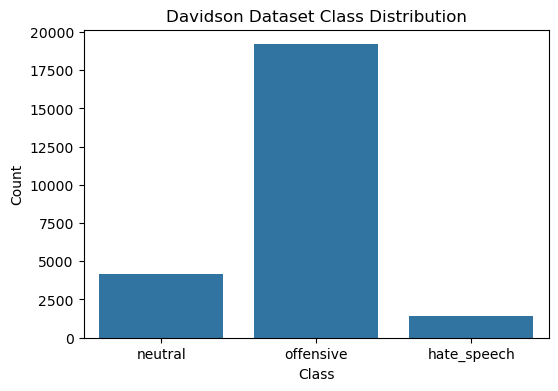


Jigsaw Dataset - Mapped Labels:
label
neutral        143346
offensive       13538
hate_speech      2687
Name: count, dtype: int64


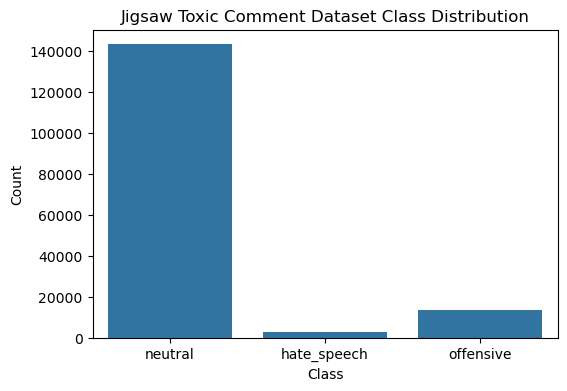

In [5]:
# Verify Davidson dataset label distribution after mapping
print("Davidson Dataset - Mapped Labels:")
print(df_davidson['label'].value_counts())

# Plot class distribution for Davidson dataset
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df_davidson)
plt.title('Davidson Dataset Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Verify Jigsaw dataset label distribution after mapping
print("\nJigsaw Dataset - Mapped Labels:")
print(df_jigsaw['label'].value_counts())

# Plot class distribution for Jigsaw dataset
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df_jigsaw)
plt.title('Jigsaw Toxic Comment Dataset Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

## 4.1 Merge Datasets and Sampling

Combine the two datasets into a single DataFrame and shuffle the data to ensure a random distribution.


In [6]:
# Combine the datasets
df_combined = pd.concat([df_davidson, df_jigsaw], ignore_index=True)

# Shuffle the combined dataset
df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)

# Check combined dataset label distribution
print("Combined Dataset Label Distribution:")
print(df_combined['label'].value_counts())


Combined Dataset Label Distribution:
label
neutral        147509
offensive       32728
hate_speech      4117
Name: count, dtype: int64


## 4.2 Sample to Class proportions
- **Neutral:** 52%
- **Offensive:** 40%
- **Hate Speech:** 8%

In [9]:
# Define total desired dataset size
total_size = 30000

# Calculate number of samples for each class
neutral_size = int(total_size * 0.52)       # 50% -> 30,000
offensive_size = int(total_size * 0.4)     # 40% -> 24,000
hate_speech_size = total_size - neutral_size - offensive_size  # 10% -> 6,000

print(f"Desired class sizes:")
print(f"Neutral: {neutral_size}")
print(f"Offensive: {offensive_size}")
print(f"Hate Speech: {hate_speech_size}")

Desired class sizes:
Neutral: 20800
Offensive: 16000
Hate Speech: 3200


## 5. Sampling from Each Class and Source

To emphasize the **Davidson** dataset (tweets) in the **Offensive** and **Hate Speech** classes, we'll allocate a higher proportion of samples from Davidson for these classes when available. In this case offensive seems to be the only option. I also considered ensuring class balance. However, while balanced is beneficial, it does not reflect world life examples, thus while I did empahsize hate nad offensive speech, neutral remains the majority of the dataset.

### **Sampling Strategy:**

- **Neutral (50%):**
  - 15% from Davidson
  - 85% from Jigsaw

- **Offensive (40%):**
  - 79% from Davidson
  - 21% from Jigsaw

- **Hate Speech (10%):**
  - 62% from Davidson
  - 38% from Jigsaw

This strategy ensures that the model has ample exposure to tweet-specific patterns in the `offensive` and `hate_speech` classes.

In [10]:
# Define sampling proportions
neutral_davidson_prop = 0.26
neutral_jigsaw_prop = 0.74

offensive_davidson_prop = 0.70
offensive_jigsaw_prop = 0.30

hate_speech_davidson_prop = 0.60
hate_speech_jigsaw_prop = 0.40

# Neutral Class Sampling
df_neutral_jigsaw = df_combined[(df_combined['label'] == 'neutral') & (df_combined['dataset'] == 'jigsaw')]
df_neutral_davidson = df_combined[(df_combined['label'] == 'neutral') & (df_combined['dataset'] == 'davidson')]

neutral_jigsaw_size = int(neutral_size * neutral_jigsaw_prop)  
neutral_davidson_size = neutral_size - neutral_jigsaw_size    

# Sample neutral from Jigsaw
if len(df_neutral_jigsaw) >= neutral_jigsaw_size:
    df_neutral_jigsaw_sampled = df_neutral_jigsaw.sample(n=neutral_jigsaw_size, random_state=42)
else:
    df_neutral_jigsaw_sampled = resample(df_neutral_jigsaw,
                                        replace=True,
                                        n_samples=neutral_jigsaw_size,
                                        random_state=42)

# Sample neutral from Davidson
if len(df_neutral_davidson) >= neutral_davidson_size:
    df_neutral_davidson_sampled = df_neutral_davidson.sample(n=neutral_davidson_size, random_state=42)
else:
    df_neutral_davidson_sampled = resample(df_neutral_davidson,
                                          replace=True,
                                          n_samples=neutral_davidson_size,
                                          random_state=42)

# Offensive Class Sampling
df_offensive_jigsaw = df_combined[(df_combined['label'] == 'offensive') & (df_combined['dataset'] == 'jigsaw')]
df_offensive_davidson = df_combined[(df_combined['label'] == 'offensive') & (df_combined['dataset'] == 'davidson')]

offensive_jigsaw_size = int(offensive_size * offensive_jigsaw_prop) 
offensive_davidson_size = offensive_size - offensive_jigsaw_size   

# Sample offensive from Jigsaw
if len(df_offensive_jigsaw) >= offensive_jigsaw_size:
    df_offensive_jigsaw_sampled = df_offensive_jigsaw.sample(n=offensive_jigsaw_size, random_state=42)
else:
    df_offensive_jigsaw_sampled = resample(df_offensive_jigsaw,
                                          replace=True,
                                          n_samples=offensive_jigsaw_size,
                                          random_state=42)

# Sample offensive from Davidson
if len(df_offensive_davidson) >= offensive_davidson_size:
    df_offensive_davidson_sampled = df_offensive_davidson.sample(n=offensive_davidson_size, random_state=42)
else:
    df_offensive_davidson_sampled = resample(df_offensive_davidson,
                                            replace=True,
                                            n_samples=offensive_davidson_size,
                                            random_state=42)

# Hate Speech Class Sampling
df_hate_jigsaw = df_combined[(df_combined['label'] == 'hate_speech') & (df_combined['dataset'] == 'jigsaw')]
df_hate_davidson = df_combined[(df_combined['label'] == 'hate_speech') & (df_combined['dataset'] == 'davidson')]

hate_speech_davidson_size = int(hate_speech_size * hate_speech_davidson_prop)
hate_speech_jigsaw_size = hate_speech_size - hate_speech_davidson_size   

# Sample hate speech from Davidson
if len(df_hate_davidson) >= hate_speech_davidson_size:
    df_hate_davidson_sampled = df_hate_davidson.sample(n=hate_speech_davidson_size, random_state=42)
else:
    df_hate_davidson_sampled = resample(df_hate_davidson,
                                       replace=True,
                                       n_samples=hate_speech_davidson_size,
                                       random_state=42)

# Sample hate speech from Jigsaw
if len(df_hate_jigsaw) >= hate_speech_jigsaw_size:
    df_hate_jigsaw_sampled = df_hate_jigsaw.sample(n=hate_speech_jigsaw_size, random_state=42)
else:
    df_hate_jigsaw_sampled = resample(df_hate_jigsaw,
                                     replace=True,
                                     n_samples=hate_speech_jigsaw_size,
                                     random_state=42)


## 6. Combine Sampled Data

Merge all the sampled data into a single balanced DataFrame.


In [11]:
# Combine all sampled data
df_balanced = pd.concat([
    df_neutral_jigsaw_sampled,
    df_neutral_davidson_sampled,
    df_offensive_jigsaw_sampled,
    df_offensive_davidson_sampled,
    df_hate_jigsaw_sampled,
    df_hate_davidson_sampled
], ignore_index=True)

# Shuffle the balanced dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

## 8. Verify the Balanced Class Distribution

Ensure that the sampling has achieved the desired class proportions:
- **Neutral:** 52% (31,200 samples)
- **Offensive:** 40% (24,000 samples)
- **Hate Speech:** 8% (4,800 samples)

Balanced Dataset Label Distribution:
label
neutral        20800
offensive      16000
hate_speech     3200
Name: count, dtype: int64


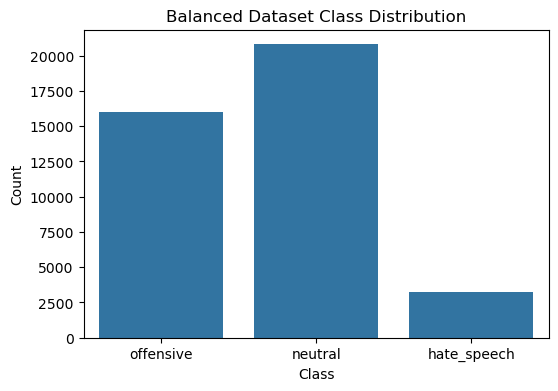

In [12]:
# Verify the class distribution
print("Balanced Dataset Label Distribution:")
print(df_balanced['label'].value_counts())

# Plot class distribution for balanced dataset
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df_balanced)
plt.title('Balanced Dataset Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


## 9. Save the Balanced Dataset

Store the balanced dataset for future use in model training.


In [13]:
# Define the path to save the balanced dataset
balanced_path = os.path.join('..', 'data', 'processed', 'balanced_dataset.csv')

# Save the balanced dataset
df_balanced.to_csv(balanced_path, index=False)
print(f"Balanced dataset saved at '{balanced_path}'.")


Balanced dataset saved at '../data/processed/balanced_dataset.csv'.


## 10. Summary of Merge and Sampling

- **Merged Datasets:** Combined Davidson (tweets) and Jigsaw (Wikipedia comments) datasets into a single DataFrame with a `dataset` identifier.
- **Balanced Classes:** Adjusted class distributions to achieve:
  - **Neutral:** 52% 
  - **Offensive:** 40% 
  - **Hate Speech:** 8% 
- **Emphasized Tweets:** Allocated higher proportions from the Davidson dataset for the `offensive` classes to ensure the model performs well on tweets.

